# Task 1 — Data, Model & Membership Inference Attack
**AI Security Issues — Final Project**


**Model:** Simple Neural Network (MLP)  
**Attack:** Membership Inference Attack

## Download Dataset via Kaggle API

Go to https://www.kaggle.com/settings → API → Create New Token  
Place the `.json` file at `C:\Users\yourusername\.kaggle\kaggle.json`

---

## 1. Download Dataset

In [22]:
import kagglehub
import os

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(f"Dataset downloaded to: {path}")

# Find the CSV file inside the downloaded folder
csv_file = None
for f in os.listdir(path):
    if f.endswith('.csv'):
        csv_file = os.path.join(path, f)
        break

print(f"CSV path: {csv_file}")

Dataset downloaded to: C:\Users\BlueberryPancake\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1
CSV path: C:\Users\BlueberryPancake\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1\IMDB Dataset.csv


## 2. Load & Explore Data

In [23]:
import pandas as pd

df = pd.read_csv(csv_file)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['sentiment'].value_counts())
df.head(3)

Shape: (50000, 2)

Columns: ['review', 'sentiment']

Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## 3. Text Preprocessing

In [24]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)        # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)     # remove special chars and numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(preprocess)

# Before / after example
print("Before:")
print(df['review'].iloc[0][:300])
print("\nAfter:")
print(df['clean_review'].iloc[0][:300])

Before:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

After:
one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximu


## 4. Encode Labels & Train/Test Split

In [25]:
from sklearn.model_selection import train_test_split

# Encode labels: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 40000
Test size:  10000


## 5. TF-IDF Vectorization

Fitted **only** on the training set to avoid data leakage.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

Feature matrix shape: (40000, 20000)


## 6. Build & Train the Model

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Convert sparse TF-IDF matrices to dense arrays
X_train_dense = X_train_tfidf.toarray().astype(np.float32)
X_test_dense  = X_test_tfidf.toarray().astype(np.float32)
y_train_arr   = y_train.values.astype(np.float32)
y_test_arr    = y_test.values.astype(np.float32)

input_dim = X_train_dense.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train_dense, y_train_arr,
    epochs=30,          
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("\nTraining complete.")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 256)               5120256   
                                                                 
 dense_4 (Dense)             (None, 64)                16448     
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 5,136,769
Trainable params: 5,136,769
Non-trainable params: 0
_________________________________________________________________
Epoch 1/30
141/141 [==============================] - 6s 40ms/step - loss: 0.3364 - accuracy: 0.8686 - val_loss: 0.2509 - val_accuracy: 0.8942
Epoch 2/30
141/141 [==============================] - 6s 39ms/step - loss: 0.1383 - accuracy: 0.9522 - val_loss: 0.2847 - val_accuracy: 0.8863
Epoch 3/30
141/141 [==

## 7. Baseline Evaluation

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

probs  = model.predict(X_test_dense, verbose=0).flatten()
y_pred = (probs >= 0.5).astype(int)

accuracy  = accuracy_score(y_test_arr, y_pred)
precision = precision_score(y_test_arr, y_pred)
recall    = recall_score(y_test_arr, y_pred)
f1        = f1_score(y_test_arr, y_pred)

print("BASELINE PERFORMANCE")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")
print()
print(classification_report(y_test_arr, y_pred, target_names=['Negative', 'Positive']))

BASELINE PERFORMANCE
  Accuracy : 0.8793
  Precision: 0.8764
  Recall   : 0.8832
  F1-Score : 0.8798

              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      5000
    Positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## 8. Save Artifacts

In [29]:
import joblib

# Save model (architecture + weights)
model.save('model.h5')

# Save the vectorizer
joblib.dump(vectorizer, 'vectorizer.pkl')

# Save all splits so every team member uses the exact same data
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',  index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',  index=False)

print("Saved: model.h5, vectorizer.pkl, X_train.csv, X_test.csv, y_train.csv, y_test.csv")

Saved: model.h5, vectorizer.pkl, X_train.csv, X_test.csv, y_train.csv, y_test.csv


---
# Membership Inference Attack (ART)

**Concept:**  
A membership inference attack tries to determine whether a given sample was part of the model's training set.  
The key intuition is that an overfitted model behaves differently on training data vs unseen data — it tends to produce **higher confidence** predictions on samples it has memorized.

The gap in our model makes it a clear target:
- Train accuracy: ~99.8%  
- Test accuracy:  ~87.8%

**How the attack works (ART `MembershipInferenceBlackBox`):**  
ART wraps the target model and trains an internal attack model that learns to distinguish members from non-members based on the target model's output probabilities. We only need to provide it with some known members (train samples) and non-members (test samples) to fit on.

### Step 0 — Install ART

In [30]:
# !pip install adversarial-robustness-toolbox --quiet

### Step 1 — Wrap the Model with ART

In [31]:
from art.estimators.classification import TensorFlowV2Classifier
import tensorflow as tf

# Use TensorFlowV2Classifier instead of KerasClassifier —
# more compatible with newer Keras versions
loss_fn = tf.keras.losses.BinaryCrossentropy()

art_classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=2,
    input_shape=(X_train_dense.shape[1],),
    loss_object=loss_fn,
    clip_values=(0.0, 1.0)
)

print("Model wrapped with ART TensorFlowV2Classifier.")

Model wrapped with ART TensorFlowV2Classifier.


### Step 2 — Set Up the Attack

In [32]:
from art.attacks.inference.membership_inference import MembershipInferenceBlackBox

# Use a subset of train/test to keep things fast
# attack_train_size  — samples used to *fit* the attack model (must be members + non-members)
# attack_test_size   — samples used to *evaluate* the attack
attack_train_size = 2000
attack_test_size  = 2000

# Members: samples the target model was trained on
member_train = X_train_dense[:attack_train_size]
member_test  = X_train_dense[attack_train_size:attack_train_size + attack_test_size]

# Non-members: samples the target model has never seen
nonmember_train = X_test_dense[:attack_train_size]
nonmember_test  = X_test_dense[attack_train_size:attack_train_size + attack_test_size]

# attack_model_type='nn' trains a small neural net as the internal attack classifier
# NEURAL NET USES TORCH, using random forest instead
attack = MembershipInferenceBlackBox(art_classifier, attack_model_type='rf')

print("Attack initialised.")

Attack initialised.


### Step 3 — Fit the Attack

In [33]:
# Fit the attack model on known members and non-members
attack.fit(
    member_train,
    y_train_arr[:attack_train_size],
    nonmember_train,
    y_test_arr[:attack_train_size]
)

print("Attack model fitted.")

Attack model fitted.


### Step 4 — Run Inference & Evaluate

In [34]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# infer() returns 1 (member) or 0 (non-member) for each sample
member_preds    = attack.infer(member_test,    y_train_arr[attack_train_size:attack_train_size + attack_test_size])
nonmember_preds = attack.infer(nonmember_test, y_test_arr[attack_train_size:attack_train_size + attack_test_size])

# Ground truth: members=1, non-members=0
y_true = np.concatenate([np.ones(attack_test_size), np.zeros(attack_test_size)])
y_pred_atk = np.concatenate([member_preds, nonmember_preds])

atk_acc = accuracy_score(y_true, y_pred_atk)

print("MEMBERSHIP INFERENCE ATTACK RESULTS")
print(f"  Attack Accuracy : {atk_acc:.4f}")
print()
print("  > Baseline (random guessing) : 0.5000")
print(f"  > Our attack achieves        : {atk_acc:.4f} — {'significant privacy leakage' if atk_acc > 0.6 else 'modest leakage'}")
print()
print(classification_report(y_true, y_pred_atk, target_names=['Non-member', 'Member']))

MEMBERSHIP INFERENCE ATTACK RESULTS
  Attack Accuracy : 0.6132

  > Baseline (random guessing) : 0.5000
  > Our attack achieves        : 0.6132 — significant privacy leakage

              precision    recall  f1-score   support

  Non-member       0.74      0.34      0.47      2000
      Member       0.57      0.88      0.70      2000

    accuracy                           0.61      4000
   macro avg       0.66      0.61      0.58      4000
weighted avg       0.66      0.61      0.58      4000



### Step 5 — Visualize the Confidence Gap

C:\Users\BlueberryPancake\AppData\Local\Temp\ipykernel_13568\2063149948.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


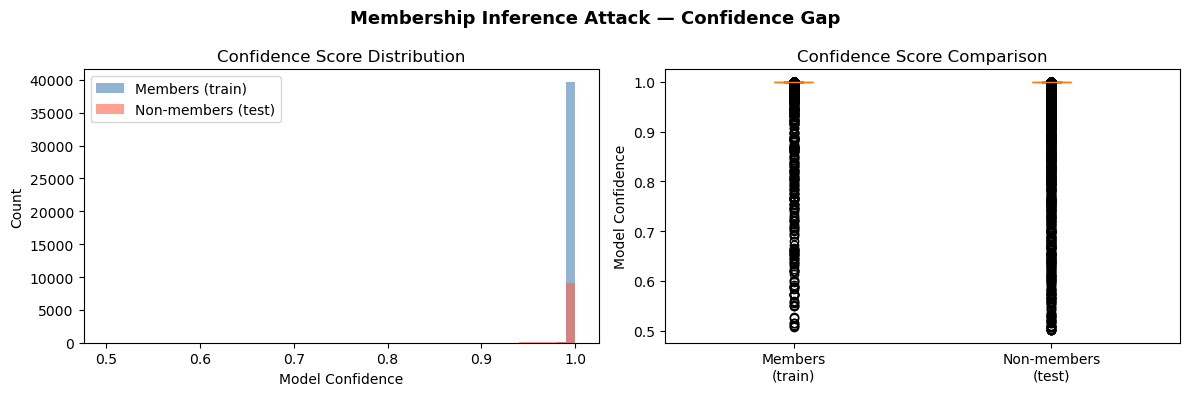

Avg confidence on TRAIN samples : 0.9987
Avg confidence on TEST  samples : 0.9864


In [35]:
import matplotlib.pyplot as plt

# Get raw confidence scores to visualize what the attack exploits
train_probs = model.predict(X_train_dense, verbose=0).flatten()
test_probs  = model.predict(X_test_dense,  verbose=0).flatten()

train_confidence = np.maximum(train_probs, 1 - train_probs)
test_confidence  = np.maximum(test_probs,  1 - test_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: confidence distributions
axes[0].hist(train_confidence, bins=50, alpha=0.6, label='Members (train)', color='steelblue')
axes[0].hist(test_confidence,  bins=50, alpha=0.6, label='Non-members (test)', color='tomato')
axes[0].set_title('Confidence Score Distribution')
axes[0].set_xlabel('Model Confidence')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
axes[1].boxplot(
    [train_confidence, test_confidence],
    labels=['Members\n(train)', 'Non-members\n(test)'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
axes[1].set_title('Confidence Score Comparison')
axes[1].set_ylabel('Model Confidence')

plt.suptitle('Membership Inference Attack — Confidence Gap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('membership_inference_attack.png', dpi=150)
plt.show()

print(f"Avg confidence on TRAIN samples : {train_confidence.mean():.4f}")
print(f"Avg confidence on TEST  samples : {test_confidence.mean():.4f}")

### Summary

| | Value |
|---|---|
| Target model train accuracy | ~99.8% |
| Target model test accuracy  | ~87.8% |
| Attack accuracy             | see output above |
| Random guessing baseline    | 50.0% |

The overfitting gap is the **root cause** of this vulnerability — the model assigns near-perfect confidence to training samples it has memorized, which ART's attack model learns to exploit.